# RCPSP with Transfer Times **and** Resource Calendars (RCPSP-TT-cal)

This notebook combines two extensions of the classical RCPSP into a single
model family:

- **Transfer times** (see [`rcpsptt.ipynb`](https://github.com/radovluk/CP_Cookbook/blob/main/notebooks/rcpsptt.ipynb)) — moving a resource unit from one activity to the next costs time $\Delta_{i,j,r}$.
- **Per-unit availability calendars** (see [`rcpsp_timeoffs.ipynb`](https://github.com/radovluk/CP_Cookbook/blob/main/notebooks/rcpsp_timeoffs.ipynb)) — each individual resource unit has its own on/off step-function $\mathcal{F}_u$.

The classical RCPSP-TT uses interchangeable units (capacity is a plain integer $C_r$).
Calendars only make sense once units have an identity, so we adopt the calendar
format (units with IDs) and attach a transfer-time matrix per resource type --
units of the same type are homogeneous w.r.t. transfer cost.

## Problem Definition

We are given a set of activities $\mathcal{A} = \{0, 1, \dots, n-1\}$ where $0$ is a
dummy *source* and $n-1$ a dummy *sink* ($p_0 = p_{n-1} = 0$). Activities are linked by
finish-to-start precedences $\mathcal{E}$. Resources are organised into **types** $k \in
\mathcal{K}$; each type owns a set of **units** $\mathcal{U}_k$, and every unit $u$ has an
availability calendar $\mathcal{F}_u(t) \in \{0,1\}$ (1 = available).

Activity $i$ requires $q_{i,k}$ units of type $k$. In the **No Migration | No
Interruption** variant, those $q_{i,k}$ units are fixed for the entire span $[s_i, e_i)$,
the span equals $p_i$ (no pauses), and each assigned unit must be continuously available.

Whenever a single unit $u$ of type $k$ finishes activity $i$ and is later used by activity
$j$, a **transfer time** $\Delta_{i,j,k}$ must pass between $e_i$ and the moment $u$ starts
working on $j$. The objective is to minimise the makespan $\operatorname{end}(a_{n-1})$.

### Notation

| Symbol | Meaning |
|---|---|
| $\mathcal{A}$ | Activities incl. source $0$ and sink $n-1$ |
| $\mathcal{E}$ | Precedence relations $(i,j)$; $\mathcal{E}^\star$ its transitive closure |
| $\mathcal{K}$ | Resource types |
| $\mathcal{U}_k$ | Units of type $k$; $\kappa(u)$ is the type of unit $u$ |
| $p_i$ | Duration (size) of activity $i$ |
| $q_{i,k}$ | Units of type $k$ required by activity $i$ |
| $\mathcal{F}_u(t)$ | Calendar of unit $u$ (1 available, 0 off); $\overline{\mathcal{F}_u}$ its complement |
| $\Delta_{i,j,k}$ | Transfer time of one unit of type $k$ from activity $i$ to $j$ |
| $\mathcal{C}_i$ | Candidate units for $i$ (units of any type it requests) |
| $T_i$ | Master interval variable of activity $i$ (size $p_i$) |
| $O_{i,u}$ | Optional interval: unit $u$ works on activity $i$ |
| $Z_{i,j,u}$ | Optional transit interval of unit $u$ from $i$ to $j$ (size $\Delta_{i,j,\kappa(u)}$) |

## Data Format & Parsing

The instance format extends the `rcpsp-timeoffs` `.data` layout with a trailing
`TRANSFER TIMES` section: one $n \times n$ matrix per resource type, where row $i$,
column $j$ gives $\Delta_{i,j,k}$. Source row and sink column are zero.

```
<num_tasks> <num_types> <num_units>
per type:    <type_id> <num_units> <unit_id_1> ...
per unit:    <unit_id> <num_steps> <t_1> <v_1> <t_2> <v_2> ...
per task:    <task_id> <size> <num_reqs>   then <type_id> <qty> lines
<num_precedences>   then <pred> <succ> lines
<num_types>         then per type: <type_id> + N rows of N integers
```

Calendar steps: value $v$ holds from $t_i$ until $t_{i+1}$; $v>0$ available, $v=0$ off.

In [1]:
with open("../data/rcpsptt_cal/00.data") as f:
    print(f.read())

# =====================================================================
# RCPSP-TT-cal  --  toy instance "00"
# RCPSP with Transfer Times AND per-unit availability calendars.
# Combines the rcpsp-timeoffs format (units with calendars) with a
# per-resource-type transfer-time matrix from rcpsptt.
# =====================================================================

# HEADER: <num_tasks> <num_types> <num_units>
5 1 2

# RESOURCE TYPES
# Format: <type_id> <num_units> <unit_id1> <unit_id2> ...
# Type 0 has 2 interchangeable units: U0 and U1
0 2 0 1

# RESOURCE UNITS (Calendars)
# Format: <unit_id> <num_steps> <t1> <v1> <t2> <v2> ...
# Step function: value v holds from time t_i until t_{i+1}.
# v > 0  => available,  v == 0 => unavailable (time-off).

# Unit 0: off [0,1), on [1,8), off [8,9), on [9,..)
0 4 0 0 1 100 8 0 9 100

# Unit 1: on [0,5), off [5,6), on [6,..)
1 3 0 100 5 0 6 100

# TASKS
# Format: <task_id> <size> <num_reqs>   then  <type_id> <qty> per requirement
# Task 0: dummy 

### Parser

In [2]:
def load_instance(filename):
    """Load an RCPSP-TT-cal instance.

    Returns (N, K, M, TASKS, TYPES, UNITS, PRECEDENCES, DELTA):
        N           number of tasks (incl. dummy source 0 and sink N-1)
        K           number of resource types
        M           number of resource units
        TASKS       [(task_id, size, [(type_id, qty), ...]), ...]
        TYPES       [(type_id, [unit_ids]), ...]
        UNITS       [(unit_id, [(time, value), ...]), ...]   (calendars)
        PRECEDENCES [(pred_task, succ_task), ...]
        DELTA       {type_id: [[Delta[i][j] for j] for i]}  transfer matrices
    """
    def next_line(f):
        while True:
            raw = f.readline()
            if not raw:
                return None
            line = raw.strip()
            if not line or line.startswith("#"):
                continue
            return [int(v) for v in line.split()]

    with open(filename) as f:
        N, K, M = next_line(f)

        TYPES = []
        for _ in range(K):
            d = next_line(f)
            TYPES.append((d[0], d[2:2 + d[1]]))

        UNITS = []
        for _ in range(M):
            d = next_line(f)
            unit_id, n_steps = d[0], d[1]
            steps = [(d[2 + 2 * i], d[3 + 2 * i]) for i in range(n_steps)]
            UNITS.append((unit_id, steps))

        TASKS = []
        for _ in range(N):
            d = next_line(f)
            task_id, size, n_reqs = d[0], d[1], d[2]
            reqs = [tuple(next_line(f)[:2]) for _ in range(n_reqs)]
            TASKS.append((task_id, size, reqs))

        n_prec = next_line(f)[0]
        PRECEDENCES = [tuple(next_line(f)[:2]) for _ in range(n_prec)]

        DELTA = {}
        head = next_line(f)
        if head is not None:
            for _ in range(head[0]):
                type_id = next_line(f)[0]
                DELTA[type_id] = [next_line(f) for _ in range(N)]

    return N, K, M, TASKS, TYPES, UNITS, PRECEDENCES, DELTA

### Helper functions

In [3]:
HORIZON = 1000

def transitive_closure(edges, n):
    """All (direct + implied) precedence pairs via Floyd-Warshall."""
    adj = [[False] * n for _ in range(n)]
    for i, j in edges:
        adj[i][j] = True
    for k in range(n):
        for i in range(n):
            if adj[i][k]:
                for j in range(n):
                    if adj[k][j]:
                        adj[i][j] = True
    return [(i, j) for i in range(n) for j in range(n) if adj[i][j]]

def get_availability(unit_id, time, res_map):
    """Calendar value of a unit at a given time (0 if before first step)."""
    return next((v for t, v in reversed(res_map[unit_id]) if time >= t), 0)

### Load the instance

In [4]:
N, K, M, TASKS, TYPES, UNITS, PRECEDENCES, DELTA = load_instance("../data/rcpsptt_cal/00.data")

TYPE_MAP  = {tid: units for tid, units in TYPES}      # type_id -> [unit_ids]
RES_MAP   = dict(UNITS)                                # unit_id -> calendar steps
UNIT_TYPE = {u: tid for tid, units in TYPES for u in units}
SIZE      = {tid: size for tid, size, _ in TASKS}

# Candidate units of each task = all units of every type it requests
CAND = {tid: [u for type_id, q in reqs if q > 0 for u in TYPE_MAP[type_id]]
        for tid, _, reqs in TASKS}

# Precedence transitive closure
E = transitive_closure(PRECEDENCES, N)
E_set = set(E)

def delta(u, i, j):
    """Transfer time of unit u (its type) from activity i to j."""
    return DELTA[UNIT_TYPE[u]][i][j]

In [5]:
def print_instance():
    print(f"{'='*64}")
    print(f"INSTANCE: {N} tasks (incl. source/sink), {K} type(s), {M} unit(s)")
    print(f"{'='*64}")
    for tid, units in TYPES:
        cal = ", ".join(f"U{u}" for u in units)
        print(f"  Type {tid}: units {{{cal}}}")
    print(f"\n{'Task':<6}{'Size':<6}{'Requirements':<22}Successors")
    print("-" * 64)
    for tid, size, reqs in TASKS:
        succ = [j for i, j in PRECEDENCES if i == tid]
        rq = ", ".join(f"{q}x T{t}" for t, q in reqs if q > 0) or "—"
        print(f"T{tid:<5}{size:<6}{rq:<22}{succ if succ else '—'}")
    print(f"\n{'Unit':<6}{'Type':<6}Available windows")
    print("-" * 64)
    for uid, steps in UNITS:
        wins = []
        for i, (t, v) in enumerate(steps):
            end = steps[i + 1][0] if i + 1 < len(steps) else "∞"
            if v > 0:
                wins.append(f"[{t},{end})")
        print(f"U{uid:<5}T{UNIT_TYPE[uid]:<5}{' '.join(wins)}")
    print(f"\n{'Transfer times':<16}(per type, Delta[i][j])")
    print("-" * 64)
    for tid, mat in DELTA.items():
        print(f"  Type {tid}:")
        header = "      " + "".join(f"T{j:<3}" for j in range(N))
        print(header)
        for i, row in enumerate(mat):
            print(f"   T{i:<2}" + "".join(f"{v:<4}" for v in row))

print_instance()

INSTANCE: 5 tasks (incl. source/sink), 1 type(s), 2 unit(s)
  Type 0: units {U0, U1}

Task  Size  Requirements          Successors
----------------------------------------------------------------
T0    0     —                     [1, 2]
T1    3     1x T0                 [3]
T2    3     1x T0                 [3]
T3    2     2x T0                 [4]
T4    0     —                     —

Unit  Type  Available windows
----------------------------------------------------------------
U0    T0    [1,8) [9,∞)
U1    T0    [0,5) [6,∞)

Transfer times  (per type, Delta[i][j])
----------------------------------------------------------------
  Type 0:
      T0  T1  T2  T3  T4  
   T0 0   0   0   0   0   
   T1 0   0   1   2   0   
   T2 0   0   0   1   0   
   T3 0   0   0   0   0   
   T4 0   0   0   0   0   


### Visualisation helper

A small Gantt drawer: one lane per unit, calendar off-periods shaded, task
intervals coloured per activity, and transfer intervals hatched.

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

COLORS = ["steelblue", "coral", "gold", "mediumpurple", "darkcyan", "sandybrown"]

def plot_schedule(task_units, transits=None, horizon=12, title=""):
    """task_units: {tid: (start, end, [unit_ids])}.
       transits:   list of (unit, i, j, start, end) or None."""
    transits = transits or []
    fig, ax = plt.subplots(figsize=(11, 0.7 * M + 1.5))
    for lane, (uid, steps) in enumerate(UNITS):
        # calendar off-periods
        for i, (t, v) in enumerate(steps):
            end = steps[i + 1][0] if i + 1 < len(steps) else horizon
            if v == 0:
                ax.barh(lane, end - t, left=t, height=0.8,
                        color="lightgray", edgecolor="none", zorder=0)
    # tasks
    for tid, (s, e, units) in task_units.items():
        if e <= s:
            continue
        for uid in units:
            lane = [l for l, (u, _) in enumerate(UNITS) if u == uid][0]
            ax.barh(lane, e - s, left=s, height=0.6, color=COLORS[tid % len(COLORS)],
                    edgecolor="black", zorder=2)
            ax.text((s + e) / 2, lane, f"T{tid}", ha="center", va="center",
                    color="white", fontweight="bold", zorder=3)
    # transits
    for uid, i, j, s, e in transits:
        if e <= s:
            continue
        lane = [l for l, (u, _) in enumerate(UNITS) if u == uid][0]
        ax.barh(lane, e - s, left=s, height=0.6, color="white", edgecolor="red",
                hatch="////", zorder=2)
        ax.text((s + e) / 2, lane, f"{i}->{j}", ha="center", va="center",
                color="red", fontsize=7, zorder=3)
    ax.set_yticks(range(M))
    ax.set_yticklabels([f"U{u}" for u, _ in UNITS])
    ax.set_xlim(0, horizon)
    ax.set_xlabel("time")
    ax.set_title(title)
    ax.grid(axis="x", linestyle=":", alpha=0.5)
    legend = [Patch(facecolor="lightgray", label="unit off (calendar)"),
              Patch(facecolor="white", edgecolor="red", hatch="////", label="transfer")]
    ax.legend(handles=legend, loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

## Formulation A — Per-Unit Sequence (transfer time as setup time)

The most compact encoding treats **each unit as a machine**. Activity $i$ picks
$q_{i,k}$ units of each requested type via an `alternative` with cardinality, every
chosen unit-interval $O_{i,u}$ is glued to the master $T_i$, and the per-unit
`noOverlap` carries a **transition matrix** equal to the transfer times. Calendars
are enforced with `forbidExtent` on each unit-interval.

$$
\begin{aligned}
\min \quad
& \operatorname{end}(T_{n-1})
& & \text{(1)} \\[2mm]
\text{s.t.} \quad
& \operatorname{endBeforeStart}(T_i, T_j),
& \forall (i,j) \in \mathcal{E}^\star
& \text{(2)} \\[1mm]
& \operatorname{alternative}(T_i, \{O_{i,u} : u \in \mathcal{U}_k\}, q_{i,k}),
& \forall i,\ \forall k : q_{i,k} > 0
& \text{(3)} \\[1mm]
& \operatorname{forbidExtent}(O_{i,u}, \overline{\mathcal{F}_u}),
& \forall i,\ \forall u \in \mathcal{C}_i
& \text{(4)} \\[1mm]
& \operatorname{noOverlap}\!\big(\operatorname{seq}_u,\ (\Delta_{i,j,\kappa(u)})\big),
& \forall u \in \mathcal{U}
& \text{(5)} \\[1mm]
& \operatorname{seq}_u = \operatorname{sequenceVar}(\{O_{i,u} : i \in \mathcal{A}\}),
& \forall u \in \mathcal{U}
& \text{(6)}
\end{aligned}
$$

**Constraints**
- **(1)** Minimise the makespan (end of the sink).
- **(2)** Precedences on the transitive closure.
- **(3)** For each requested type, select exactly $q_{i,k}$ units; cardinality `alternative` binds each chosen $O_{i,u}$ to share start/end with $T_i$.
- **(4)** Each chosen unit-interval must lie inside the unit's availability windows.
- **(5)** On each unit, its task-intervals do not overlap **and** the gap between any two consecutive activities is at least the transfer time, supplied as the transition matrix.

**Semantics of the transfer (variant A).** The transfer is only an implicit *gap*
between two intervals on the same unit. It is **not** itself calendar-constrained — the
unit may be "in transit" across an off-period. This is the cheap, idiomatic encoding; if
the transit must physically occur during available time, use Formulation B.

### IBM CPO implementation

In [7]:
from docplex.cp.model import (CpoModel, CpoStepFunction, CpoTransitionMatrix,
                              interval_var, sequence_var, alternative,
                              end_before_start, no_overlap, forbid_extent,
                              minimize, end_of)

def build_step_fn(steps, horizon=HORIZON):
    f = CpoStepFunction()
    for i, (t, v) in enumerate(steps):
        end = steps[i + 1][0] if i + 1 < len(steps) else horizon
        f.set_value(t, end, v)
    return f

In [8]:
mdl = CpoModel(name="rcpsptt_cal_setup_cpo")
avail = {u: build_step_fn(RES_MAP[u]) for u in range(M)}

# (variables) master + optional per-unit intervals
T = {i: interval_var(size=SIZE[i], name=f"T{i}") for i in range(N)}
O = {(i, u): interval_var(size=SIZE[i], optional=True, name=f"O_{i}_{u}")
     for i in range(N) for u in CAND[i]}

# (1) objective
mdl.add(minimize(end_of(T[N - 1])))

# (2) precedences
mdl.add([end_before_start(T[i], T[j]) for i, j in E])

# (3) cardinality alternative per requested type
for tid, _, reqs in TASKS:
    for type_id, qty in reqs:
        if qty > 0:
            mdl.add(alternative(T[tid], [O[(tid, u)] for u in TYPE_MAP[type_id]],
                                cardinality=qty))

# (4) calendar compliance per unit-interval
for (i, u), iv in O.items():
    mdl.add(forbid_extent(iv, avail[u]))

# (5)+(6) per-unit sequence with transfer times as transition matrix
for u in range(M):
    tasks_u = [i for i in range(N) if (i, u) in O]
    ivs = [O[(i, u)] for i in tasks_u]
    tm = CpoTransitionMatrix(size=len(tasks_u))
    for a, ia in enumerate(tasks_u):
        for b, ib in enumerate(tasks_u):
            tm.set_value(a, b, delta(u, ia, ib))
    seq = sequence_var(ivs, types=list(range(len(tasks_u))), name=f"seq_{u}")
    mdl.add(no_overlap(seq, tm))

status: Optimal | makespan: 8
  T0: [0,0)  units=[]
  T1: [0,3)  units=[1]
  T2: [1,4)  units=[0]
  T3: [6,8)  units=[0, 1]
  T4: [8,8)  units=[]


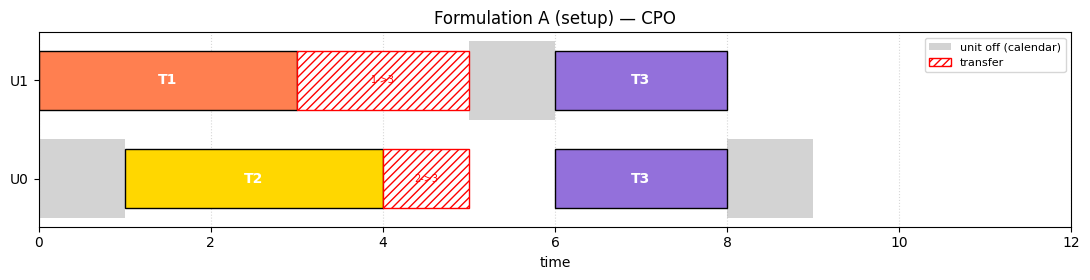

In [9]:
sol = mdl.solve(TimeLimit=30, LogVerbosity="Quiet")
print("status:", sol.get_solve_status(), "| makespan:", sol.get_objective_values()[0])

task_units, transits = {}, []
for i in range(N):
    v = sol.get_var_solution(T[i])
    units = [u for (ii, u) in O if ii == i and sol.get_var_solution(O[(i, u)]).is_present()]
    task_units[i] = (v.get_start(), v.get_end(), units)
    print(f"  T{i}: [{v.get_start()},{v.get_end()})  units={units}")
# reconstruct implicit transfers (gaps on a unit between consecutive activities)
for u in range(M):
    seq_tasks = sorted((task_units[i][0], i) for i in range(N)
                       if u in task_units[i][2] and task_units[i][1] > task_units[i][0])
    for (s1, i), (s2, j) in zip(seq_tasks, seq_tasks[1:]):
        e_i = task_units[i][1]
        if delta(u, i, j) > 0:
            transits.append((u, i, j, e_i, e_i + delta(u, i, j)))
plot_schedule(task_units, transits, horizon=12, title="Formulation A (setup) — CPO")

### OptalCP implementation

OptalCP has no cardinality `alternative`, so requirement (3) is expressed as
`sum(presence) == q` plus `startAtStart` / `endAtEnd` synchronisation with the master.
The transition matrix is passed directly to `sequenceVar.noOverlap`.

In [10]:
import optalcp as cp

m = cp.Model(name="rcpsptt_cal_setup_optal")
availo = {u: m.step_function([[t, v] for t, v in RES_MAP[u]]) for u in range(M)}

To = {i: m.interval_var(length=SIZE[i], name=f"T{i}") for i in range(N)}
Oo = {(i, u): m.interval_var(length=SIZE[i], optional=True, name=f"O_{i}_{u}")
      for i in range(N) for u in CAND[i]}

m.minimize(To[N - 1].end())
m.enforce([To[i].end_before_start(To[j]) for i, j in E])

# (3) cardinality via presence sum + sync
for tid, _, reqs in TASKS:
    for type_id, qty in reqs:
        if qty > 0:
            ci = [Oo[(tid, u)] for u in TYPE_MAP[type_id]]
            m.enforce(m.sum([iv.presence() for iv in ci]) == qty)
            m.enforce([To[tid].start_at_start(iv) for iv in ci])
            m.enforce([To[tid].end_at_end(iv) for iv in ci])

# (4) calendars
for (i, u), iv in Oo.items():
    iv.forbid_extent(availo[u])

# (5)+(6) per-unit sequence with transitions
for u in range(M):
    tasks_u = [i for i in range(N) if (i, u) in Oo]
    ivs = [Oo[(i, u)] for i in tasks_u]
    trans = [[delta(u, ia, ib) for ib in tasks_u] for ia in tasks_u]
    seq = m.sequence_var(ivs, types=list(range(len(tasks_u))))
    m.enforce(seq.no_overlap(trans))

res = m.solve({"timeLimit": 30, "nbWorkers": 8, "logLevel": 0})
print("makespan:", res.objective, "| bound:", res.objective_bound)
for i in range(N):
    s, e = res.solution.get_start(To[i]), res.solution.get_end(To[i])
    us = [u for (ii, u) in Oo if ii == i and res.solution.is_present(Oo[(i, u)])]
    print(f"  T{i}: [{s},{e})  units={us}")

makespan: 8.0 | bound: 8.0
  T0: [0,0)  units=[]
  T1: [0,3)  units=[1]
  T2: [1,4)  units=[0]
  T3: [6,8)  units=[0, 1]
  T4: [8,8)  units=[]


## Formulation B — Per-Unit Flow with Explicit Transit Intervals

Here the transfer becomes a **first-class interval** $Z_{i,j,u}$ of length
$\Delta_{i,j,\kappa(u)}$, placed between $O_{i,u}$ and $O_{j,u}$ on unit $u$. Both task and
transit intervals share the unit's `noOverlap`, and the transit is **calendar-constrained**
as well (`forbidExtent`). This is the per-unit analogue of the flow formulation in
`rcpsptt.ipynb`, where the unit identity replaces the integer flow.

$$
\begin{aligned}
\min \quad
& \operatorname{end}(T_{n-1})
& & \text{(1)} \\[2mm]
\text{s.t.} \quad
& \operatorname{endBeforeStart}(T_i, T_j),
& \forall (i,j) \in \mathcal{E}^\star
& \text{(2)} \\[1mm]
& \operatorname{alternative}(T_i, \{O_{i,u} : u \in \mathcal{U}_k\}, q_{i,k}),
& \forall i,\ \forall k
& \text{(3)} \\[1mm]
& \operatorname{forbidExtent}(O_{i,u}, \overline{\mathcal{F}_u}),
& \forall i,\ \forall u \in \mathcal{C}_i
& \text{(4)} \\[1mm]
& \operatorname{forbidExtent}(Z_{i,j,u}, \overline{\mathcal{F}_u}),
& \forall (i,j,u),\ \Delta_{i,j,\kappa(u)} > 0
& \text{(5)} \\[1mm]
& \operatorname{presenceOf}(Z_{i,j,u}) \Rightarrow \operatorname{presenceOf}(O_{i,u}) \wedge \operatorname{presenceOf}(O_{j,u}),
& \forall (i,j,u)
& \text{(6)} \\[1mm]
& \operatorname{endBeforeStart}(O_{i,u}, Z_{i,j,u}),\ \operatorname{endBeforeStart}(Z_{i,j,u}, O_{j,u}),
& \forall (i,j,u)
& \text{(7)} \\[1mm]
& \operatorname{noOverlap}(\{O_{i,u}\}_i \cup \{Z_{i,j,u}\}_{i,j}),
& \forall u \in \mathcal{U}
& \text{(8)}
\end{aligned}
$$

**Constraints**
- **(1)–(4)** as in Formulation A.
- **(5)** The transit interval itself must lie inside the unit's available windows (**variant B semantics**).
- **(6)** A transit may exist only if the unit truly serves both endpoints.
- **(7)** A transit is sandwiched between the two activities it links.
- **(8)** Tasks and transits of a unit never overlap (a unit can do only one thing at a time).

The candidate transit set excludes precedence-conflicting pairs $((j,i)\in\mathcal{E}^\star)$
and the dummy source/sink (their transfer times are zero).

### IBM CPO implementation

In [11]:
from docplex.cp.model import presence_of, if_then

mdl = CpoModel(name="rcpsptt_cal_flow_cpo")
avail = {u: build_step_fn(RES_MAP[u]) for u in range(M)}

T = {i: interval_var(size=SIZE[i], name=f"T{i}") for i in range(N)}
O = {(i, u): interval_var(size=SIZE[i], optional=True, name=f"O_{i}_{u}")
     for i in range(N) for u in CAND[i]}

# transit candidates (i,j,u): non-conflicting pair, u eligible for both
Z = {}
for u in range(M):
    for i in range(N):
        for j in range(N):
            if i == j or (j, i) in E_set:
                continue
            if u in CAND[i] and u in CAND[j]:
                Z[(i, j, u)] = interval_var(size=delta(u, i, j), optional=True,
                                            name=f"Z_{i}_{j}_{u}")

mdl.add(minimize(end_of(T[N - 1])))
mdl.add([end_before_start(T[i], T[j]) for i, j in E])

for tid, _, reqs in TASKS:
    for type_id, qty in reqs:
        if qty > 0:
            mdl.add(alternative(T[tid], [O[(tid, u)] for u in TYPE_MAP[type_id]],
                                cardinality=qty))

# (4) calendar on tasks, (5) calendar on transits
for (i, u), iv in O.items():
    mdl.add(forbid_extent(iv, avail[u]))
for (i, j, u), iv in Z.items():
    if delta(u, i, j) > 0:
        mdl.add(forbid_extent(iv, avail[u]))

# (6)+(7) presence + temporal linkage
for (i, j, u), z in Z.items():
    mdl.add(if_then(presence_of(z), presence_of(O[(i, u)])))
    mdl.add(if_then(presence_of(z), presence_of(O[(j, u)])))
    mdl.add(end_before_start(O[(i, u)], z))
    mdl.add(end_before_start(z, O[(j, u)]))

# (8) per-unit no-overlap over tasks + transits
for u in range(M):
    ivs = [O[(i, u)] for i in range(N) if (i, u) in O]
    ivs += [Z[(i, j, uu)] for (i, j, uu) in Z if uu == u]
    mdl.add(no_overlap(ivs))

status: Optimal | makespan: 8
  T0: [0,0)  units=[]
  T1: [1,4)  units=[0]
  T2: [0,3)  units=[1]
  T3: [6,8)  units=[0, 1]
  T4: [8,8)  units=[]


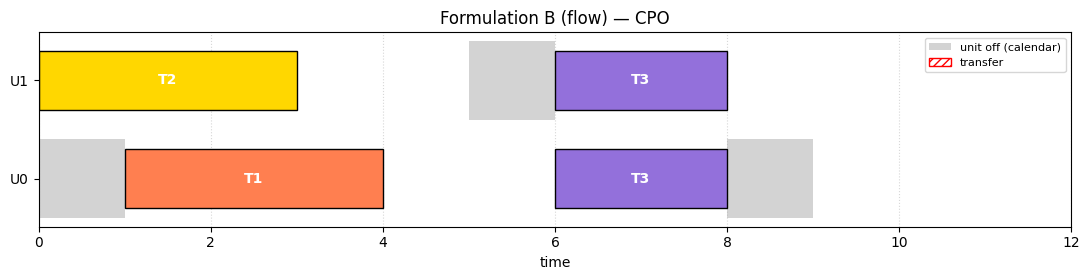

In [12]:
sol = mdl.solve(TimeLimit=30, LogVerbosity="Quiet")
print("status:", sol.get_solve_status(), "| makespan:", sol.get_objective_values()[0])

task_units, transits = {}, []
for i in range(N):
    v = sol.get_var_solution(T[i])
    units = [u for (ii, u) in O if ii == i and sol.get_var_solution(O[(i, u)]).is_present()]
    task_units[i] = (v.get_start(), v.get_end(), units)
    print(f"  T{i}: [{v.get_start()},{v.get_end()})  units={units}")
for (i, j, u), z in Z.items():
    zv = sol.get_var_solution(z)
    if zv.is_present():
        transits.append((u, i, j, zv.get_start(), zv.get_end()))
        print(f"  transit U{u}: T{i}->T{j} [{zv.get_start()},{zv.get_end()})")
plot_schedule(task_units, transits, horizon=12, title="Formulation B (flow) — CPO")

### OptalCP implementation

In [13]:
m = cp.Model(name="rcpsptt_cal_flow_optal")
availo = {u: m.step_function([[t, v] for t, v in RES_MAP[u]]) for u in range(M)}

To = {i: m.interval_var(length=SIZE[i], name=f"T{i}") for i in range(N)}
Oo = {(i, u): m.interval_var(length=SIZE[i], optional=True, name=f"O_{i}_{u}")
      for i in range(N) for u in CAND[i]}
Zo = {}
for u in range(M):
    for i in range(N):
        for j in range(N):
            if i == j or (j, i) in E_set:
                continue
            if u in CAND[i] and u in CAND[j]:
                Zo[(i, j, u)] = m.interval_var(length=delta(u, i, j), optional=True,
                                               name=f"Z_{i}_{j}_{u}")

m.minimize(To[N - 1].end())
m.enforce([To[i].end_before_start(To[j]) for i, j in E])

for tid, _, reqs in TASKS:
    for type_id, qty in reqs:
        if qty > 0:
            ci = [Oo[(tid, u)] for u in TYPE_MAP[type_id]]
            m.enforce(m.sum([iv.presence() for iv in ci]) == qty)
            m.enforce([To[tid].start_at_start(iv) for iv in ci])
            m.enforce([To[tid].end_at_end(iv) for iv in ci])

for (i, u), iv in Oo.items():
    iv.forbid_extent(availo[u])
for (i, j, u), iv in Zo.items():
    if delta(u, i, j) > 0:
        iv.forbid_extent(availo[u])

# presence linkage (a <= b means "a present implies b present" for 0/1 presence)
for (i, j, u), z in Zo.items():
    m.enforce(z.presence() <= Oo[(i, u)].presence())
    m.enforce(z.presence() <= Oo[(j, u)].presence())
    m.enforce(Oo[(i, u)].end_before_start(z))
    m.enforce(z.end_before_start(Oo[(j, u)]))

for u in range(M):
    ivs = [Oo[(i, u)] for i in range(N) if (i, u) in Oo]
    ivs += [Zo[(i, j, uu)] for (i, j, uu) in Zo if uu == u]
    m.enforce(m.no_overlap(ivs))

res = m.solve({"timeLimit": 30, "nbWorkers": 8, "logLevel": 0})
print("makespan:", res.objective, "| bound:", res.objective_bound)

makespan: 8.0 | bound: 8.0


## What the Calendar and the Transfer Times Each Cost

To see that **both** features bind, solve the same instance four ways: with/without
calendars and with/without transfer times (Formulation A, CPO).

In [14]:
def solve_variant(use_cal, use_tt):
    mm = CpoModel()
    av = {u: build_step_fn(RES_MAP[u]) for u in range(M)}
    Tv = {i: interval_var(size=SIZE[i]) for i in range(N)}
    Ov = {(i, u): interval_var(size=SIZE[i], optional=True)
          for i in range(N) for u in CAND[i]}
    for tid, _, reqs in TASKS:
        for type_id, qty in reqs:
            if qty > 0:
                mm.add(alternative(Tv[tid], [Ov[(tid, u)] for u in TYPE_MAP[type_id]],
                                   cardinality=qty))
    mm.add(minimize(end_of(Tv[N - 1])))
    mm.add([end_before_start(Tv[i], Tv[j]) for i, j in E])
    if use_cal:
        for (i, u), iv in Ov.items():
            mm.add(forbid_extent(iv, av[u]))
    for u in range(M):
        tu = [i for i in range(N) if (i, u) in Ov]
        tm = CpoTransitionMatrix(size=len(tu))
        for a, ia in enumerate(tu):
            for b, ib in enumerate(tu):
                tm.set_value(a, b, delta(u, ia, ib) if use_tt else 0)
        sq = sequence_var([Ov[(i, u)] for i in tu], types=list(range(len(tu))))
        mm.add(no_overlap(sq, tm))
    r = mm.solve(TimeLimit=10, LogVerbosity="Quiet")
    return r.get_objective_values()[0]

print(f"pure RCPSP (no cal, no TT): {solve_variant(False, False)}")
print(f"transfer times only       : {solve_variant(False, True)}")
print(f"calendars only            : {solve_variant(True, False)}")
print(f"calendars + transfer times: {solve_variant(True, True)}")

pure RCPSP (no cal, no TT): 5
transfer times only       : 7
calendars only            : 8
calendars + transfer times: 8


On this toy instance the result is **5 / 7 / 8 / 8**: transfer times alone push the
makespan from 5 to 7, calendars alone push it to 8, and combining them stays at 8 —
the calendar-induced delay before activity $T_3$ happens to create enough idle time to
*absorb* the transfers. Constraints do not simply add up; whichever is tighter at the
critical activity dominates. On larger instances they usually compound.

## Beyond Variant 1 — Migration and Interruption

Variants 2–4 relax the *no-migration* and *no-interruption* assumptions. The key
obstacle is that **transfer times need unit identity**: the aggregate-capacity trick
used for plain calendar problems (summing $\mathcal{F}_u$ into a capacity profile)
throws away *which* unit serves a task, so a per-unit movement — and its $\Delta$ — can
no longer be expressed. Every model below therefore keeps per-unit intervals.

Two shared helpers: `build_modes` (unit-combinations satisfying a task's requirements)
and `joint_intensity` (a step function that is on only when *all* units of a mode are
available).

In [15]:
from itertools import combinations, product

def build_modes():
    """task -> list of unit-tuples satisfying its requirements."""
    res = {}
    for tid, _, reqs in TASKS:
        active = [(ty, q) for ty, q in reqs if q > 0]
        if not active:
            res[tid] = [()]
            continue
        combos = [list(combinations(TYPE_MAP[ty], q)) for ty, q in active]
        res[tid] = [tuple(sorted({r for grp in c for r in grp})) for c in product(*combos)]
    return res

def joint_intensity(units, value=100):
    """Step list: `value` when ALL units available at t, else 0."""
    if not units:
        return [(0, value)]
    times = sorted({0} | {t for u in units for t, _ in RES_MAP[u]})
    return [(t, value if all(get_availability(u, t, RES_MAP) > 0 for u in units) else 0)
            for t in times]

## Variant 2 — Migration | No Interruption

The task runs **continuously** (length $= p_i$), but the *set* of units serving it may
change over time. At every instant exactly $q_{i,k}$ units of type $k$ are active. A unit
contributes one contiguous block $O_{i,u}\subseteq T_i$; when it later serves another
activity, the transfer time applies (per-unit transition matrix).

$$
\begin{aligned}
\min\ & \operatorname{end}(T_{n-1}) & & \text{(1)} \\[1mm]
& \operatorname{endBeforeStart}(T_i, T_j) & \forall (i,j)\in\mathcal{E}^\star & \text{(2)} \\[1mm]
& \operatorname{alwaysIn}\Big(\textstyle\sum_{u\in\mathcal{U}_k}\operatorname{pulse}(O_{i,u},1),\ T_i,\ q_{i,k},\ q_{i,k}\Big) & \forall i,\forall k & \text{(3)} \\[1mm]
& \textstyle\sum_{u\in\mathcal{U}_k}\operatorname{sizeOf}(O_{i,u}) = q_{i,k}\,p_i & \forall i,\forall k & \text{(4)} \\[1mm]
& O_{i,u}\subseteq T_i & \forall i,\forall u & \text{(5)} \\[1mm]
& \operatorname{forbidExtent}(O_{i,u},\overline{\mathcal{F}_u}) & \forall i,\forall u & \text{(6)} \\[1mm]
& \operatorname{noOverlap}\!\big(\operatorname{seq}_u,\ (\Delta_{i,j,\kappa(u)})\big) & \forall u & \text{(7)}
\end{aligned}
$$

**(3)** forces exactly $q_{i,k}$ active units throughout $T_i$. **(4)** fixes the total
work. **(5)** keeps each block inside the task span. **(7)** is the per-unit no-overlap with
transfer-time transitions. In OptalCP, `alwaysIn` is unavailable, so (3)+(4) become a
constant cumul bound `≤ q` plus the same total-length equation (pointwise $\le q$ with
area $q\,p_i$ forces $=q$).

### IBM CPO implementation

status: Optimal | makespan: 8
  T0: [0,0) blocks=[]
  T1: [1,4) blocks=[(0, 1, 4)]
  T2: [0,3) blocks=[(1, 0, 3)]
  T3: [6,8) blocks=[(0, 6, 8), (1, 6, 8)]
  T4: [8,8) blocks=[]


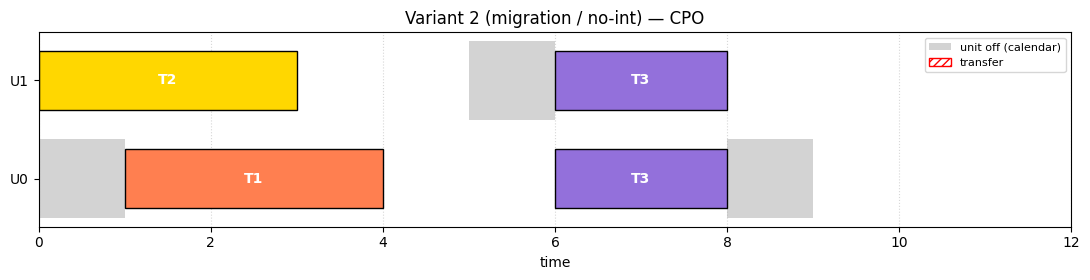

In [16]:
from docplex.cp.model import always_in, size_of, pulse, start_of

mdl = CpoModel(name="rcpsptt_cal_mig_noint_cpo")
avail = {u: build_step_fn(RES_MAP[u]) for u in range(M)}
T = {i: interval_var(size=SIZE[i], name=f"T{i}") for i in range(N)}
O = {(i, u): interval_var(optional=True, name=f"O_{i}_{u}")
     for i in range(N) for u in CAND[i]}

mdl.add(minimize(end_of(T[N - 1])))
mdl.add([end_before_start(T[i], T[j]) for i, j in E])
for tid, size, reqs in TASKS:
    for ty, q in reqs:
        if q <= 0:
            continue
        units = TYPE_MAP[ty]
        mdl.add(always_in(sum(pulse(O[(tid, u)], 1) for u in units), T[tid], q, q))
        mdl.add(sum(size_of(O[(tid, u)], 0) for u in units) == q * size)
        for u in units:
            mdl.add(start_of(O[(tid, u)], 0) >= start_of(T[tid]))
            mdl.add(end_of(O[(tid, u)], 0) <= end_of(T[tid]))
for (i, u), iv in O.items():
    mdl.add(forbid_extent(iv, avail[u]))
for u in range(M):
    items = [i for i in range(N) if (i, u) in O]
    ivs = [O[(i, u)] for i in items]
    tm = CpoTransitionMatrix(size=len(items))
    for a, ia in enumerate(items):
        for b, ib in enumerate(items):
            tm.set_value(a, b, delta(u, ia, ib))
    mdl.add(no_overlap(sequence_var(ivs, types=list(range(len(items)))), tm))

sol = mdl.solve(TimeLimit=30, LogVerbosity="Quiet")
print("status:", sol.get_solve_status(), "| makespan:", sol.get_objective_values()[0])
task_units = {}
for i in range(N):
    v = sol.get_var_solution(T[i])
    blocks = []
    for u in CAND[i]:
        ov = sol.get_var_solution(O[(i, u)])
        if ov.is_present() and ov.get_end() > ov.get_start():
            blocks.append((u, ov.get_start(), ov.get_end()))
    task_units[i] = (v.get_start(), v.get_end(), [u for u, _, _ in blocks])
    print(f"  T{i}: [{v.get_start()},{v.get_end()}) blocks={blocks}")
plot_schedule(task_units, [], horizon=12, title="Variant 2 (migration / no-int) — CPO")

### OptalCP implementation

In [17]:
m = cp.Model(name="rcpsptt_cal_mig_noint_optal")
availo = {u: m.step_function([[t, v] for t, v in RES_MAP[u]]) for u in range(M)}
To = {i: m.interval_var(length=SIZE[i], name=f"T{i}") for i in range(N)}
Oo = {(i, u): m.interval_var(optional=True, name=f"O_{i}_{u}")
      for i in range(N) for u in CAND[i]}
m.minimize(To[N - 1].end())
m.enforce([To[i].end_before_start(To[j]) for i, j in E])
for tid, size, reqs in TASKS:
    for ty, q in reqs:
        if q <= 0:
            continue
        units = TYPE_MAP[ty]
        m.enforce(m.sum([m.pulse(Oo[(tid, u)], 1) for u in units]) <= q)
        m.enforce(m.sum([Oo[(tid, u)].length().guard(0) for u in units]) == q * size)
        for u in units:
            m.enforce(To[tid].start_before_start(Oo[(tid, u)]))
            m.enforce(Oo[(tid, u)].end_before_end(To[tid]))
for (i, u), iv in Oo.items():
    iv.forbid_extent(availo[u])
for u in range(M):
    items = [i for i in range(N) if (i, u) in Oo]
    ivs = [Oo[(i, u)] for i in items]
    trans = [[delta(u, ia, ib) for ib in items] for ia in items]
    m.enforce(m.sequence_var(ivs, types=list(range(len(items)))).no_overlap(trans))
res = m.solve({"timeLimit": 30, "nbWorkers": 8, "logLevel": 0})
print("makespan:", res.objective, "| bound:", res.objective_bound)

makespan: 8.0 | bound: 8.0


## Variant 3 — Migration | Interruption

The most general variant: the task may be **paused** *and* change its unit set. It is split
into up to $W$ preemptive segments $S_{i,w}$ (chained in time); the master $T_i$ spans them
and total worked time equals $p_i$. Each present segment selects exactly $q_{i,k}$ units
(cardinality `alternative`), so coverage is always $0$ or exactly $q$. Transfers apply
between distinct activities on a unit (same-task segments carry $\Delta_{i,i}=0$).

$$
\begin{aligned}
\min\ & \operatorname{end}(T_{n-1}) & & \text{(1)} \\[1mm]
& \operatorname{endBeforeStart}(T_i, T_j) & \forall (i,j)\in\mathcal{E}^\star & \text{(2)} \\[1mm]
& \operatorname{span}(T_i, \{S_{i,w}\}_w) & \forall i & \text{(3)} \\[1mm]
& \textstyle\sum_w \operatorname{lengthOf}(S_{i,w}) = p_i & \forall i & \text{(4)} \\[1mm]
& \operatorname{endBeforeStart}(S_{i,w}, S_{i,w+1}) & \forall i, w & \text{(5)} \\[1mm]
& \operatorname{alternative}(S_{i,w}, \{O_{i,w,u}\}_{u\in\mathcal{U}_k}, q_{i,k}) & \forall i,w,k & \text{(6)} \\[1mm]
& \operatorname{forbidExtent}(O_{i,w,u}, \overline{\mathcal{F}_u}) & \forall i,w,u & \text{(7)} \\[1mm]
& \operatorname{noOverlap}\!\big(\operatorname{seq}_u,\ (\Delta_{i,j,\kappa(u)})\big) & \forall u & \text{(8)}
\end{aligned}
$$

### IBM CPO implementation

In [18]:
from docplex.cp.model import span, length_of, presence_of

MAX_SEGS = 4
modes = build_modes()
mdl = CpoModel(name="rcpsptt_cal_mig_int_cpo")
avail = {u: build_step_fn(RES_MAP[u]) for u in range(M)}
T = {i: interval_var(name=f"T{i}") for i in range(N)}
S = {(i, w): interval_var(optional=True, name=f"S_{i}_{w}")
     for i in range(N) for w in range(MAX_SEGS)}
O = {(i, w, u): interval_var(optional=True, name=f"O_{i}_{w}_{u}")
     for i in range(N) for w in range(MAX_SEGS) for u in CAND[i]}
mdl.add(minimize(end_of(T[N - 1])))
mdl.add([end_before_start(T[i], T[j]) for i, j in E])
for i, size, reqs in TASKS:
    mdl.add(span(T[i], [S[(i, w)] for w in range(MAX_SEGS)]))
    for w in range(MAX_SEGS - 1):
        mdl.add(end_before_start(S[(i, w)], S[(i, w + 1)]))
        mdl.add(presence_of(S[(i, w + 1)]) <= presence_of(S[(i, w)]))
    mdl.add(sum(length_of(S[(i, w)], 0) for w in range(MAX_SEGS)) == size)
    if size > 0:
        mdl.add(presence_of(S[(i, 0)]) == 1)
    for w in range(MAX_SEGS):
        for ty, q in reqs:
            if q > 0:
                mdl.add(alternative(S[(i, w)], [O[(i, w, u)] for u in TYPE_MAP[ty]], cardinality=q))
for (i, w, u), iv in O.items():
    mdl.add(forbid_extent(iv, avail[u]))
for u in range(M):
    items = [(i, w) for (i, w, uu) in O if uu == u]
    ivs = [O[(i, w, u)] for i, w in items]
    tasks = [i for i, _ in items]
    uniq = sorted(set(tasks)); idx = {t: n for n, t in enumerate(uniq)}
    tm = CpoTransitionMatrix(size=len(uniq))
    for a in uniq:
        for b in uniq:
            tm.set_value(idx[a], idx[b], delta(u, a, b))
    mdl.add(no_overlap(sequence_var(ivs, types=[idx[t] for t in tasks]), tm))

sol = mdl.solve(TimeLimit=30, LogVerbosity="Quiet")
print("status:", sol.get_solve_status(), "| makespan:", sol.get_objective_values()[0])
for i in range(N):
    segs = []
    for w in range(MAX_SEGS):
        sv = sol.get_var_solution(S[(i, w)])
        if sv.is_present() and sv.get_end() > sv.get_start():
            us = [u for u in CAND[i] if sol.get_var_solution(O[(i, w, u)]).is_present()]
            segs.append((sv.get_start(), sv.get_end(), us))
    if segs:
        print(f"  T{i}: {segs}")

status: Optimal | makespan: 8
  T1: [(1, 4, [0])]
  T2: [(1, 4, [1])]
  T3: [(6, 8, [0, 1])]


### OptalCP implementation

In [19]:
MAX_SEGS = 4
m = cp.Model(name="rcpsptt_cal_mig_int_optal")
availo = {u: m.step_function([[t, v] for t, v in RES_MAP[u]]) for u in range(M)}
To = {i: m.interval_var(name=f"T{i}") for i in range(N)}
So = {(i, w): m.interval_var(optional=True, name=f"S_{i}_{w}")
      for i in range(N) for w in range(MAX_SEGS)}
Oo = {(i, w, u): m.interval_var(optional=True, name=f"O_{i}_{w}_{u}")
      for i in range(N) for w in range(MAX_SEGS) for u in CAND[i]}
m.minimize(To[N - 1].end())
m.enforce([To[i].end_before_start(To[j]) for i, j in E])
for i, size, reqs in TASKS:
    m.enforce(m.span(To[i], [So[(i, w)] for w in range(MAX_SEGS)]))
    for w in range(MAX_SEGS - 1):
        m.enforce(So[(i, w)].end_before_start(So[(i, w + 1)]))
        m.enforce(So[(i, w + 1)].presence() <= So[(i, w)].presence())
    m.enforce(m.sum([So[(i, w)].length().guard(0) for w in range(MAX_SEGS)]) == size)
    if size > 0:
        m.enforce(So[(i, 0)].presence() == 1)
    for w in range(MAX_SEGS):
        for ty, q in reqs:
            if q > 0:
                ci = [Oo[(i, w, u)] for u in TYPE_MAP[ty]]
                m.enforce(m.sum([iv.presence() for iv in ci]) == q * So[(i, w)].presence())
                m.enforce([So[(i, w)].start_at_start(iv) for iv in ci])
                m.enforce([So[(i, w)].end_at_end(iv) for iv in ci])
for (i, w, u), iv in Oo.items():
    iv.forbid_extent(availo[u])
for u in range(M):
    items = [(i, w) for (i, w, uu) in Oo if uu == u]
    ivs = [Oo[(i, w, u)] for i, w in items]
    tasks = [i for i, _ in items]
    uniq = sorted(set(tasks)); idx = {t: n for n, t in enumerate(uniq)}
    trans = [[delta(u, a, b) for b in uniq] for a in uniq]
    m.enforce(m.sequence_var(ivs, types=[idx[t] for t in tasks]).no_overlap(trans))
res = m.solve({"timeLimit": 30, "nbWorkers": 8, "logLevel": 0})
print("makespan:", res.objective, "| bound:", res.objective_bound)

makespan: 8.0 | bound: 8.0


## Variant 4 — No Migration | Blocked Interruption

The task keeps **one fixed unit set** (a *mode*), but may pause while any assigned unit is
unavailable — and the units stay *blocked* (reserved) through the pause. Work accrues only
under the **joint intensity** $\mathcal{G}_{i,m}(t)=\min_{u\in m}\mathcal{F}_u(t)$. The mode
interval occupies its units across the whole span, so transfers between distinct activities
on a unit use the transition matrix as before.

$$
\begin{aligned}
\min\ & \operatorname{end}(T_{n-1}) & & \text{(1)} \\[1mm]
& \operatorname{endBeforeStart}(T_i, T_j) & \forall (i,j)\in\mathcal{E}^\star & \text{(2)} \\[1mm]
& \operatorname{alternative}(T_i, \{O_{i,m}\}_{m\in\mathcal{M}_i}) & \forall i & \text{(3)} \\[1mm]
& \operatorname{sizeOf}(O_{i,m}) = \textstyle\int \mathcal{G}_{i,m}\,\mathrm{d}t = p_i & \forall i,m & \text{(4)} \\[1mm]
& \operatorname{forbidStart}(O_{i,m}, \mathcal{G}_{i,m}) & \forall i,m & \text{(5)} \\[1mm]
& \operatorname{noOverlap}\!\big(\operatorname{seq}_u,\ (\Delta_{i,j,\kappa(u)})\big) & \forall u & \text{(6)}
\end{aligned}
$$

In CPO the work content is set with the interval's `intensity` (size $=p_i$ then means
$p_i$ units of full-intensity work). OptalCP has no per-interval intensity, so instead
`integral(G, O) == size` plus `forbid_start`.

### IBM CPO implementation

status: Optimal | makespan: 8
  T0: [0,0) units=[]
  T1: [1,4) units=[0]
  T2: [0,3) units=[1]
  T3: [6,8) units=[0, 1]
  T4: [8,8) units=[]


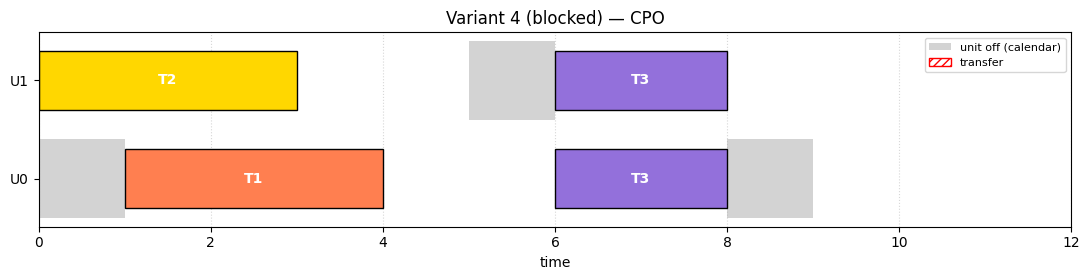

In [20]:
from docplex.cp.model import forbid_start

modes = build_modes()
G = {(i, mi): build_step_fn(joint_intensity(modes[i][mi]))
     for i in range(N) for mi in range(len(modes[i]))}
mdl = CpoModel(name="rcpsptt_cal_blocked_cpo")
T = {i: interval_var(name=f"T{i}") for i in range(N)}
O = {(i, mi): interval_var(size=SIZE[i], intensity=G[(i, mi)], optional=True, name=f"O_{i}_{mi}")
     for i in range(N) for mi in range(len(modes[i]))}
mdl.add(minimize(end_of(T[N - 1])))
mdl.add([end_before_start(T[i], T[j]) for i, j in E])
for i in range(N):
    mdl.add(alternative(T[i], [O[(i, mi)] for mi in range(len(modes[i]))]))
for (i, mi), iv in O.items():
    mdl.add(forbid_start(iv, G[(i, mi)]))
for u in range(M):
    items = [(i, mi) for (i, mi) in O if u in modes[i][mi]]
    ivs = [O[k] for k in items]
    tasks = [i for i, _ in items]
    uniq = sorted(set(tasks)); idx = {t: n for n, t in enumerate(uniq)}
    tm = CpoTransitionMatrix(size=len(uniq))
    for a in uniq:
        for b in uniq:
            tm.set_value(idx[a], idx[b], delta(u, a, b))
    mdl.add(no_overlap(sequence_var(ivs, types=[idx[t] for t in tasks]), tm))

sol = mdl.solve(TimeLimit=30, LogVerbosity="Quiet")
print("status:", sol.get_solve_status(), "| makespan:", sol.get_objective_values()[0])
task_units = {}
for i in range(N):
    v = sol.get_var_solution(T[i])
    chosen = next((modes[i][mi] for mi in range(len(modes[i]))
                   if sol.get_var_solution(O[(i, mi)]).is_present()), ())
    task_units[i] = (v.get_start(), v.get_end(), list(chosen))
    print(f"  T{i}: [{v.get_start()},{v.get_end()}) units={list(chosen)}")
plot_schedule(task_units, [], horizon=12, title="Variant 4 (blocked) — CPO")

### OptalCP implementation

In [21]:
modes = build_modes()
m = cp.Model(name="rcpsptt_cal_blocked_optal")
Go = {(i, mi): m.step_function(joint_intensity(modes[i][mi], value=1))
      for i in range(N) for mi in range(len(modes[i]))}
To = {i: m.interval_var(name=f"T{i}") for i in range(N)}
Oo = {(i, mi): m.interval_var(optional=True, name=f"O_{i}_{mi}")
      for i in range(N) for mi in range(len(modes[i]))}
m.minimize(To[N - 1].end())
m.enforce([To[i].end_before_start(To[j]) for i, j in E])
for i in range(N):
    m.enforce(m.alternative(To[i], [Oo[(i, mi)] for mi in range(len(modes[i]))]))
for i, size, _ in TASKS:
    if size > 0:
        for mi in range(len(modes[i])):
            m.enforce(m.integral(Go[(i, mi)], Oo[(i, mi)]).guard(size) == size)
for (i, mi), iv in Oo.items():
    if modes[i][mi]:
        iv.forbid_start(Go[(i, mi)])
for u in range(M):
    items = [(i, mi) for (i, mi) in Oo if u in modes[i][mi]]
    ivs = [Oo[k] for k in items]
    tasks = [i for i, _ in items]
    uniq = sorted(set(tasks)); idx = {t: n for n, t in enumerate(uniq)}
    trans = [[delta(u, a, b) for b in uniq] for a in uniq]
    m.enforce(m.sequence_var(ivs, types=[idx[t] for t in tasks]).no_overlap(trans))
res = m.solve({"timeLimit": 30, "nbWorkers": 8, "logLevel": 0})
print("makespan:", res.objective, "| bound:", res.objective_bound)

makespan: 8.0 | bound: 8.0


## The Six Variants (Outlook)

This notebook builds **variants 1–4** in full (CPO + OptalCP). They differ in whether a
task may *migrate* (change its unit set mid-execution) and whether it may be *interrupted*
(paused). All four are also packaged in the `cpsolve` framework under
`RCPSP-TT|cal,...|Cmax`. The last two are sketched only.

| # | Migration | Interruption | Status | Encoding |
|---|-----------|--------------|--------|----------|
| 1 | no | no | ✅ built | per-unit sequence / flow + transition matrix |
| 2 | yes | no | ✅ built | per-unit blocks + `alwaysIn` (CPO) / `≤q`+area (Optal) |
| 3 | yes | yes | ✅ built | preemptive segments + per-segment cardinality |
| 4 | no | blocked | ✅ built | modes + joint intensity + `forbidStart` |
| 5 | no | free | ⬜ sketch | as 4 but units released during pauses |
| 6 | mixed | no | ⬜ sketch | variants 1 & 2 per resource type |

On the toy instance all four built variants reach makespan **8**. The full formal
definition of all six lives in `cpsolve/docs/rcpsptt_cal_design.md`.

## Additional Resources

- **RCPSP-TT** base notebook: [`rcpsptt.ipynb`](https://github.com/radovluk/CP_Cookbook/blob/main/notebooks/rcpsptt.ipynb)
- **RCPSP with calendars** (six variants): [`rcpsp_timeoffs.ipynb`](https://github.com/radovluk/CP_Cookbook/blob/main/notebooks/rcpsp_timeoffs.ipynb)
- **Setup-time / transition matrices**: [`rcpsp_setup.ipynb`](https://github.com/radovluk/CP_Cookbook/blob/main/notebooks/rcpsp_setup.ipynb)
- Design document for the combined problem: `cpsolve/docs/rcpsptt_cal_design.md`